In [1]:
import torch

In [2]:
import torch.nn as nn

In [ ]:
# 示例1：使用类别索引作为目标
# 创建交叉熵损失函数
loss = nn.CrossEntropyLoss()
# 创建3个样本，每个样本有5个特征的输入张量，启用梯度计算
input = torch.randn(3, 5, requires_grad=True)
# 创建3个目标标签，每个标签是0-4之间的随机整数
target = torch.empty(3, dtype=torch.long).random_(5)
# 计算损失
output = loss(input, target)
# 反向传播计算梯度
output.backward()

print("Example 1: Class indices")
print(f"Input shape: {input.shape}")
print(f"Target: {target}")
print(f"Loss: {output.item():.4f}")
print()

# 示例2：使用类别概率作为目标
# 当target包含类别概率时，它应该由软标签组成——也就是说，每个target条目应该表示
# 给定数据样本的可能类别上的概率分布，其中单个概率在[0,1]之间，总分布之和为1。
# 这就是为什么在上面的类别概率示例中对target应用了softmax()函数。
#
# PyTorch不会验证target中提供的值是否在[0,1]范围内，或者每个数据样本的分布之和是否为1。
# 不会发出警告，用户有责任确保target包含有效的概率分布。
# 提供任意值可能会产生误导性的损失值和训练期间不稳定的梯度。
# 创建3个样本，每个样本有5个特征的输入张量，启用梯度计算
input = torch.randn(3, 5, requires_grad=True)
# 创建目标概率分布：随机张量经过softmax使其值在[0,1]范围内且每行和为1
target = torch.randn(3, 5).softmax(dim=1)
# 计算损失
output = loss(input, target)
# 反向传播计算梯度
output.backward()

print("Example 2: Class probabilities")
print(f"Input shape: {input.shape}")
print(f"Target shape: {target.shape}")
print(f"Target sum per sample: {target.sum(dim=1)}")
print(f"Loss: {output.item():.4f}")

Example 1: Class indices
Input shape: torch.Size([3, 5])
Target: tensor([3, 4, 4])
Loss: 1.5427

Example 2: Class probabilities
Input shape: torch.Size([3, 5])
Target shape: torch.Size([3, 5])
Target sum per sample: tensor([1.0000, 1.0000, 1.0000])
Loss: 2.0739


Incorrect target probabilities:
Min value: -1.0496, Max value: 2.0297
Sum per sample: tensor([2.8444, 0.2462, 0.8873])
Loss value: 4.6380



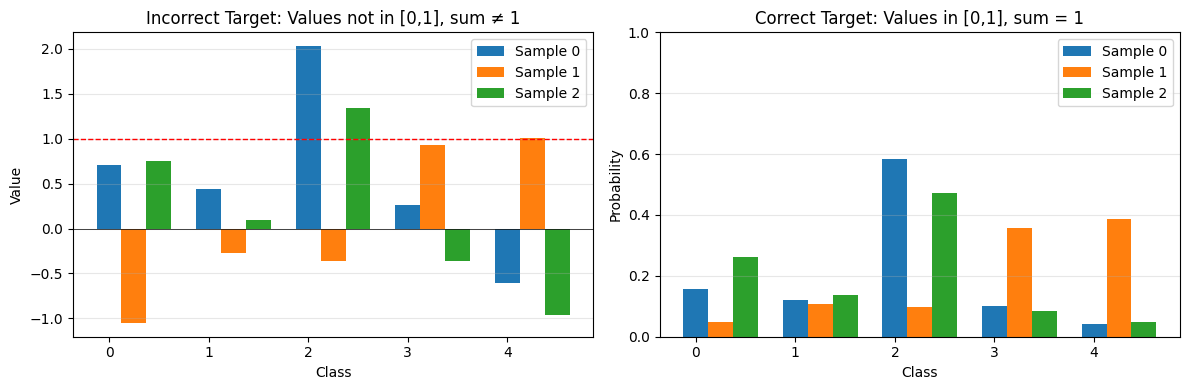

Correct target probabilities:
Min value: 0.0417, Max value: 0.5830
Sum per sample: tensor([1.0000, 1.0000, 1.0000])
Loss value: 2.5535


In [ ]:
# 目标类别概率指定不正确的示例
import matplotlib.pyplot as plt
import numpy as np

loss = nn.CrossEntropyLoss()
torch.manual_seed(283)
input = torch.randn(3, 5, requires_grad=True)
target = torch.randn(3, 5)

# 可视化不正确的目标概率
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 绘图1：不正确的目标（不在[0,1]范围内且总和不为1）
ax = axes[0]
target_np = target.numpy()
for i, row in enumerate(target_np):
    ax.bar(np.arange(5) + i*0.25, row, width=0.25, label=f'样本 {i}')
ax.set_xlabel('类别')
ax.set_ylabel('数值')
ax.set_title('不正确的目标：数值不在[0,1]范围内，总和≠1')
ax.legend()
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axhline(y=1, color='r', linestyle='--', linewidth=1, label='有效范围[0,1]')
ax.grid(axis='y', alpha=0.3)

print("不正确的目标概率：")
print(f"最小值：{target.min().item():.4f}，最大值：{target.max().item():.4f}")
print(f"每个样本的总和：{target.sum(dim=1)}")
print(f"损失值：{loss(input, target).item():.4f}")
print()

# 目标类别概率指定正确的示例
target_new = target.softmax(dim=1)

# 绘图2：正确的目标（在[0,1]范围内且总和为1）
ax = axes[1]
target_new_np = target_new.numpy()
for i, row in enumerate(target_new_np):
    ax.bar(np.arange(5) + i*0.25, row, width=0.25, label=f'样本 {i}')
ax.set_xlabel('类别')
ax.set_ylabel('概率')
ax.set_title('正确的目标：数值在[0,1]范围内，总和=1')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("正确的目标概率：")
print(f"最小值：{target_new.min().item():.4f}，最大值：{target_new.max().item():.4f}")
print(f"每个样本的总和：{target_new.sum(dim=1)}")
print(f"损失值：{loss(input, target_new).item():.4f}")